## Implémentation de la structure triple réseau de neurone

Les auteurs proposent d'intégrer la condition d'AOA directement dans les algorithmes de réseau de neurones. Ils utilisent une structure avec 3 types de NN différents. Il s'agit d'obtenir la forme du SDF en résolvant le problème de minimax antagoniste (GAN).
1. GAN (Generative Adversarial Network): l'adversaire qui cherche à trouver la fonction de conditionnement $g$ (ie une fonction telle que $\mathbb{E}[M_{t+1}R_{t+1,i}^e g(I_t, I_{t,i})] = 0$) qui génère les plus grandes erreurs d'évaluation (mispricing) pour un SDF donné. 
2. Feedforward Neural Net:  modélisateur qui cherche à trouver les poids $\omega(.)$ du SDF qui minimisent cette erreur maximale.
3. LSTM (Long-Short-Term-Memory): permet de résumer la dynamique complexe et de long terme d'un très grand nombre de séries temporelles macroéconomiques en un petit nombre de "variables d'état" cachées.

Le réseau minimise sa fonction de perte, ici l'erreur d'évaluation issue de la condition d'absence d'arbitrage. 

Les réseaux de neurones seront codés avec PyTorch. Tout est implémenté dans les fichiers `networks.py` et `gan_engine.py`. Je rappelle ici le principe de la triple structure.

#### 1. LSTM
But de ce réseau de neurones: au lieu de passer directrement en argument les valeurs macro au modélisateur, on détermine les variables d'états qui conduisent son évolution. Nécessite de stationnariser les séries temporelles en entrée pour régler le problème de non-markovianité. 

Sortie: $h_t:=h^{LSTM}(x_0,\dots,x_t)$ où $x_t$ désigne la transformation stationnarisée de $I_t$, la variable macro en $t$.

#### 2. Modélisateur: réseau SDF

La première composante du GAN est un réseau modélisateur interagissant avec un adversaire, dont l'objectif est d'estimer les poids des actions dans les portefeuilles de test fournis par l'adversaire (via l'estimateur de la fonction $\hat{g}$) optimaux pour le problème de minimisation donné par la condition d'AOA $$\mathcal{L}_{SDF}(\theta_{SDF}) = \left\| \frac{1}{T} \sum_{t=1}^{T-1} \left( M_{t+1}(\theta_{SDF}) \cdot \mathbf{R}_{t+1}^e \cdot \mathbf{g}(\theta_{ADV}, I_{t}) \right) \right\|^2.$$
Il prend en entrée l'estimateur $\hat{g}$ et les états macro fournis par le LSTM $(I_t,I_{t,i})$

#### 3. Réseau adverse

Le but de l'adversaire est de produire les "pires" portefeuilles de test, ie ceux qui maximisent la fonction de perte donnée par le même objectif que précédemment. En augmentant le poids des portefeuilles à forte perte par rapport à l'objectif, l'adversaire "met en difficulté" le modélisateur. Le processus s'arrête quand le problème de minimax est optimalement résolu.

In [7]:
%load_ext autoreload
%autoreload 2

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset 

# Tes modules
from ml_in_finance_ensae.data import DataPaths, load_all_test_assets_excess, load_macro_fred # Tes fonctions d'import
from ml_in_finance_ensae.data_utils import AssetPricingDataset, apply_stationarity_transforms, add_group_stats
from ml_in_finance_ensae.networks import SDFNetwork, MacroLSTM, AdversarialNetwork
from ml_in_finance_ensae.gan_engine import GANTrainer, GANTrainerEnsemble
from ml_in_finance_ensae.metrics import evaluate_performance, calculate_sharpe_ratio, calculate_r2_scores, evaluate_performance_ensemble

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
# A. Import macro et stationnarisation
raw_macro, tcodes = load_macro_fred('data/raw/2026-03-MD.csv')
# Appliquer tcode individuel d'abord
df_macro = apply_stationarity_transforms(raw_macro, tcodes) 
df_macro = add_group_stats(df_macro) 

# C. Normalisation Macro (Z-score obligatoire pour le LSTM)
df_macro = (df_macro - df_macro.mean()) / df_macro.std()

# D. Import des Rendements (FF25 + Ind49 = 74 actifs)
returns = load_all_test_assets_excess(DataPaths())
returns = returns / 100.0

# Aligner les dates entre Macro et Returns
common_idx = returns.index.intersection(df_macro.index)
returns = returns.loc[common_idx]
df_macro = df_macro.loc[common_idx]

/Users/daniel/Desktop/ENSAE/Cours 3A/ML_in_Finance_ENSAE/src/ml_in_finance_ensae/data_utils.py:66: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_transformed[col] = transforms[code](data[col])
/Users/daniel/Desktop/ENSAE/Cours 3A/ML_in_Finance_ENSAE/src/ml_in_finance_ensae/data_utils.py:66: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_transformed[col] = transforms[code](data[col])
/Users/daniel/Desktop/ENSAE/Cours 3A/ML_in_Finance_ENSAE/src/ml_in_finance_ensae/data_utils.py:66: PerformanceWarning: DataFrame is highly fragm

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N_ASSETS = returns.shape[1] 
N_MACRO = df_macro.shape[1] 
HIDDEN_MACRO = 4
N_INSTRUMENTS = 8 # Nombre de portefeuilles créés par l'adversaire

# Réseaux
lstm = MacroLSTM(input_dim=N_MACRO, lstm_hidden_dim=HIDDEN_MACRO).to(device)
sdf = SDFNetwork(char_dim=N_ASSETS, macro_dim=HIDDEN_MACRO).to(device)
adv = AdversarialNetwork(char_dim=N_ASSETS, macro_dim=HIDDEN_MACRO, output_dim=N_INSTRUMENTS).to(device)

trainer = GANTrainer(sdf, adv, lstm, lr_sdf=1e-4, lr_adv=1e-3)

In [10]:
split = int(len(returns) * 0.8)

train_ret = returns.iloc[:split]
test_ret = returns.iloc[split:]

train_macro_raw = df_macro.iloc[:split]
test_macro_raw = df_macro.iloc[split:]

# 2. Normalisation de la Macro (Crucial pour le LSTM)
# On calcule moyenne et std UNIQUEMENT sur le train
macro_mean = train_macro_raw.mean()
macro_std = train_macro_raw.std()

# On remplace les std nulles par 1 pour éviter les divisions par zéro
macro_std = macro_std.replace(0, 1)

train_macro = (train_macro_raw - macro_mean) / macro_std
test_macro = (test_macro_raw - macro_mean) / macro_std # On utilise la moyenne du train !

# 3. Remplissage des NaNs (Sécurité après normalisation)
train_macro = train_macro.fillna(0)
test_macro = test_macro.fillna(0)

# Dataloaders (batch_size=1 car Nt peut varier et pour la conditionnelle)
train_ds = AssetPricingDataset(train_ret,train_macro, lookback=12)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=False)

history = {"sdf_loss": [], "adv_loss": []}

for epoch in range(50):
    epoch_s, epoch_a = 0, 0
    for chars, macro, ret in train_loader:
        # Rappel : chars sera torch.eye(74) dans ton dataset
        l_s, l_a = trainer.train_step(chars.to(device), macro.to(device), ret.to(device))
        epoch_s += l_s
        epoch_a += l_a
    
    history["sdf_loss"].append(epoch_s / len(train_loader))
    history["adv_loss"].append(epoch_a / len(train_loader))



--- RÉSULTATS HORS-ÉCHANTILLON ---
Sharpe Ratio du SDF : 0.3837
R2 Prédictif : 0.0904


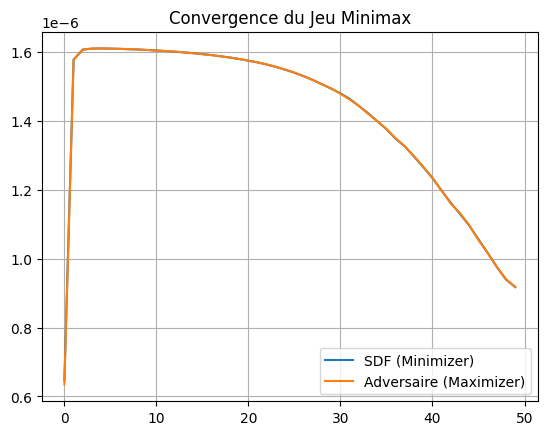

In [12]:
test_ds = AssetPricingDataset(test_ret, test_macro, lookback=12)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

# Calcul des métriques (Sharpe, R2 Cross-sectional)
metrics = evaluate_performance(trainer, test_loader, device)

print("\n--- RÉSULTATS HORS-ÉCHANTILLON ---")
print(f"Sharpe Ratio du SDF : {metrics['Sharpe_Ratio']:.4f}")
print(f"R2 Prédictif : {metrics['R2_CrossSectional']:.4f}")

#Visualisation des pertes
plt.plot(history["sdf_loss"], label="SDF (Minimizer)")
plt.plot(history["adv_loss"], label="Adversaire (Maximizer)")
plt.legend()
plt.grid()
plt.title("Convergence du Jeu Minimax")
plt.show()